# Part 1: Checking for quality issues

For this first part I want to check if data is missing, broken or suspicious. Below is a list of questions that this part intends to answer.

* What data do we have that shouldn't be null?
user_id, name, time, rating, gmap_id

* What metadata types do we have that shouldn't be null?
name, address, gmap_id, category, avg_rating, num_of_reviews

* Do we have duplicate entries in our data or metadata?

In [3]:
import sys
import pandas as pd


# open the JSON files
try:
    rd1 = pd.read_json('data/review-Georgia.json', lines=True, chunksize=1000)
    rd2 = pd.read_json('data/meta-Georgia.json', lines=True, chunksize=1000)
except FileNotFoundError:
    print("File not found")
    sys.exit()

# Check for corresponding gmap_ids
# set up sets because we don't need to worry about duplicates... yet
gmap_id_dset = set()
gmap_id_mset = set()
# append set in chunks for both data and metadata
for chunk in rd1:
    gmap_id_dset|=set(chunk['gmap_id'])
for chunk in rd2:
    gmap_id_mset|=set(chunk['gmap_id'])
# check for gmap_id in data with no corresponding gmap_id in metadata
missing_list = gmap_id_dset - gmap_id_mset
if len(missing_list) > 0:
    print("Missing gmap_ids found:")
    print(list(missing_list))
else:
    print("There are no missing gmap_ids")



There are no missing gmap_ids


It is reassuring to know that there are no missing gmap_ids.

Now to check for duplicates. I decided to count any part of the metadata with the same Name, Address, and gmap_id as a duplicate since no two restaurants would share these three variables and not be a duplicate.

In [3]:
import sys
import pandas as pd

# open the JSON file
try:
    rd2 = pd.read_json('data/meta-Georgia.json', lines=True)
except FileNotFoundError:
    print("File not found")
    sys.exit()

# just get the number of duplicated rows.
print("Number of duplicated rows in metadata:")
print(rd2.duplicated(subset=['name', 'address', 'gmap_id']).sum())


Number of duplicated rows in metadata:
986


A bit concerning. We'll have to remove this after we get the number of duplicated rows in the data.

This will have to be done slightly differently as the file in question is too large for my computer to have the whole file open at once. I will open it in chunks.

In [2]:
import sys
import pandas as pd
# this is more complicated than the last script
duplicate_count = 0
try:
    # make a set (a data type that can't have duplicates)
    keys_seen = set()
    # open the data file in chunks of 1000
    data = pd.read_json('data/review-Georgia.json', lines=True, chunksize=1000)
    for chunk in data:
        # zip allows for parallel iteration, allowing for us to speed up this process
        keys = zip(chunk['user_id'], chunk['time'], chunk['gmap_id'])
        for key in keys:
            if key in keys_seen:
                duplicate_count += 1
            else:
                keys_seen.add(key)
except FileNotFoundError:
    print("File not found")
    sys.exit()

print("Number of duplicated rows in metadata:")
print(duplicate_count)


Number of duplicated rows in metadata:
322360


Hundreds of thousands of duplicates is terrible. Now to remove these duplicates.

# Part 2: Complete transformation

The objectives of these two scripts are to:
* Remove duplicates and useless labels
* Replace the pics with the number of pictures
* Place the new .json file within the data folder


In [11]:
import pandas as pd
try:
    rd1 = pd.read_json('data/meta-Georgia.json', lines=True)
    rd1.drop(labels=['description', 'price', 'MISC', 'state', 'relative_results', 'url'], axis=1, inplace=True)
    # drop duplicates from file
    rd1.drop_duplicates(subset=['name', 'address', 'gmap_id'], inplace=True)
    # return cleaned file
    rd1.to_json('data/meta-Georgia_cleaned.json', orient='records', lines=True)
except FileNotFoundError:
    print("File not found")

This reduced the size of the metadata file by 74.39%

In [13]:
import pandas as pd
keys_seen = set()
boolean_mask = []
try:
    data = pd.read_json('data/review-Georgia.json', lines=True, chunksize=1000, dtype={'user_id':str, 'gmap_id':str})
    for chunk in data:
        chunk.drop(labels=['name', 'text', 'resp'], axis=1, inplace=True)
        chunk['pics'] = chunk['pics'].apply(lambda x: len(x) if isinstance(x, list) else 0)
        keys = chunk[['user_id', 'time', 'gmap_id']].itertuples(index=False, name=None)
        for key in keys:
            if key in keys_seen:
                boolean_mask.append(False)
            else:
                boolean_mask.append(True)
                keys_seen.add(key)
        chunk[boolean_mask].to_json('data/review-Georgia_cleaned.json', orient='records', lines=True, mode='a')
        boolean_mask = []
except FileNotFoundError:
    print("File not found")
except Exception as e:
    print(e)


This reduced the size of the data file by 61.21%

# Part 3: EDA
Next, I need to do basic analysis of the variables listed in the cleaned .json files.



In [1]:
import pandas as pd
try:
    print("Metadata Statistics")
    df = pd.read_json('data/meta-Georgia_cleaned.json', lines=True)
    print(df.describe())

except FileNotFoundError:
    print("File not found")

Metadata Statistics
            latitude      longitude     avg_rating  num_of_reviews
count  165395.000000  165395.000000  165395.000000   165395.000000
mean       33.432707     -83.858679       4.259773      145.357109
std         0.950851       2.404695       0.676245      369.566285
min        25.126484     -88.100026       1.000000        1.000000
25%        33.041988     -84.472016       4.000000        8.000000
50%        33.773949     -84.218039       4.400000       35.000000
75%        34.000048     -83.658343       4.800000      118.000000
max        42.639763     180.000000       5.000000     9998.000000


Some latitudes and longitudes are improperly entered. We can see that the minimum latitude is south of most of Florida, the maximum latitude is located in the northern U.S. The minimum longitude is west of Georgia's western border, and the maximum longitude is near the international date line.

The overwhelmingly majority of the average rating is positive. The number of reviews that a particular business has ranges from 1-9998.
I had to create a version of the review data including only the variables that would be useful with df.describe.

In [ ]:
import pandas as pd
import numpy as np
try:
    df = pd.read_json('data/review-Georgia_cleaned.json', lines=True, dtype={'user_id':str, 'time':np.uint64, 'rating':np.int8, 'gmap_id':str}, chunksize=10000)
    for chunk in df:
        chunk.drop(labels=['user_id', 'gmap_id'], axis=1, inplace=True)
        chunk.to_json('data/review-Georgia_CandR.json', orient='records', lines=True, mode='a')
except FileNotFoundError:
    print("File not found")

In [1]:
import pandas as pd
import numpy as np

try:
    df = pd.read_json('data/review-Georgia_CandR.json', lines=True, dtype={'time':np.uint64, 'rating':np.int8, 'pics':np.uint8})
    # no pandas I don't want this in scientific notation
    pd.set_option('display.float_format', lambda x: f'{x:.2f}')
    print(df.describe())
except FileNotFoundError:
    print("File not found")


                  time      rating        pics
count      23707799.00 23570222.00 23707799.00
mean  1551798490370.16        4.23        0.06
std     44324114719.32        1.24        0.73
min    946598400000.00        1.00        0.00
25%   1523875184762.50        4.00        0.00
50%   1555365798320.00        5.00        0.00
75%   1582721919769.00        5.00        0.00
max   1631158941334.00        5.00       50.00


I saw RAM usage go up to almost 15GB while running this script.
Next, let's make a histogram to get a better visual.

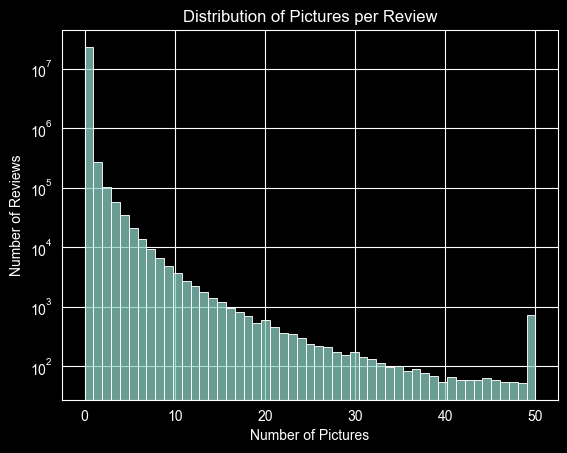

In [6]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

try:
    df = pd.read_json('data/review-Georgia_CandR.json', lines=True, dtype={'time':np.uint64, 'rating':np.int8, 'pics':np.uint8})
    #pic_counts = df['pics'].value_counts().sort_index()
    #print(pic_counts)
    plot = sns.histplot(df['pics'], bins=51)
    plt.xlabel("Number of Pictures")
    plt.ylabel("Number of Reviews")
    plt.title("Distribution of Pictures per Review")
    plot.set_yscale('log')
    plt.show()
except FileNotFoundError:
    print("File not found")